# 04 — Context-Aware Recommender
**Contributors:** James O'Brien · Marco Vidal  
**Group 2 | Inside Airbnb Madrid**

**Context dimensions:**

| Dimension | Values | Source |
|-----------|--------|--------|
| `season` | winter / spring / summer / autumn | Review date month |
| `trip_purpose` | leisure / business | Weekday + solo=business; else leisure |
| `is_peak` | True / False | July, August, December |
| `group_size_proxy` | solo / couple / small\_group / large\_group | `accommodates` |

**Method:** Pre-filtering CARS — filter training reviews to the matching context,  
compute a context-specific Bayesian Average, apply user hard filters, rank.

1. Context labelling of training reviews  
2. Statistical validation (ANOVA, Chi-squared)  
3. Context effect visualisations  
4. CARS implementation and three persona demos  
5. Context Relevance metric + Evaluation

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')
print('✓ Libraries loaded')

✓ Libraries loaded


In [1]:
listings = pd.read_csv('data/listings.csv.gz', low_memory=False)
reviews  = pd.read_csv('data/reviews.csv',     low_memory=False)
reviews['date'] = pd.to_datetime(reviews['date'])
# [Core cleaning applied — price, ratings, amenity flags, Bayesian avg]
SPLIT_DATE = pd.Timestamp('2024-07-01')
train_rev = reviews[reviews['date'] <  SPLIT_DATE].copy()
test_rev  = reviews[reviews['date'] >= SPLIT_DATE].copy()
print(f'Train: {len(train_rev):,}  |  Test: {len(test_rev):,}')

Train: 862,549  |  Test: 413,443


In [1]:
def get_season(month):
    if month in [12,1,2]: return 'winter'
    if month in [3,4,5]:  return 'spring'
    if month in [6,7,8]:  return 'summer'
    return 'autumn'

train_rev['month']       = train_rev['date'].dt.month
train_rev['season']      = train_rev['month'].apply(get_season)
train_rev['is_weekend']  = (train_rev['date'].dt.dayofweek >= 4).astype(int)
train_rev['trip_purpose']= np.where(train_rev['is_weekend']==0, 'business', 'leisure')
train_rev['context']     = train_rev['season'] + '_' + train_rev['trip_purpose']
print(train_rev['context'].value_counts().to_string())

context
spring_leisure     248006
autumn_leisure     219304
summer_leisure     204973
winter_leisure     190266
spring_business     62001
autumn_business     54826
summer_business     51243
winter_business     32930
dtype: int64


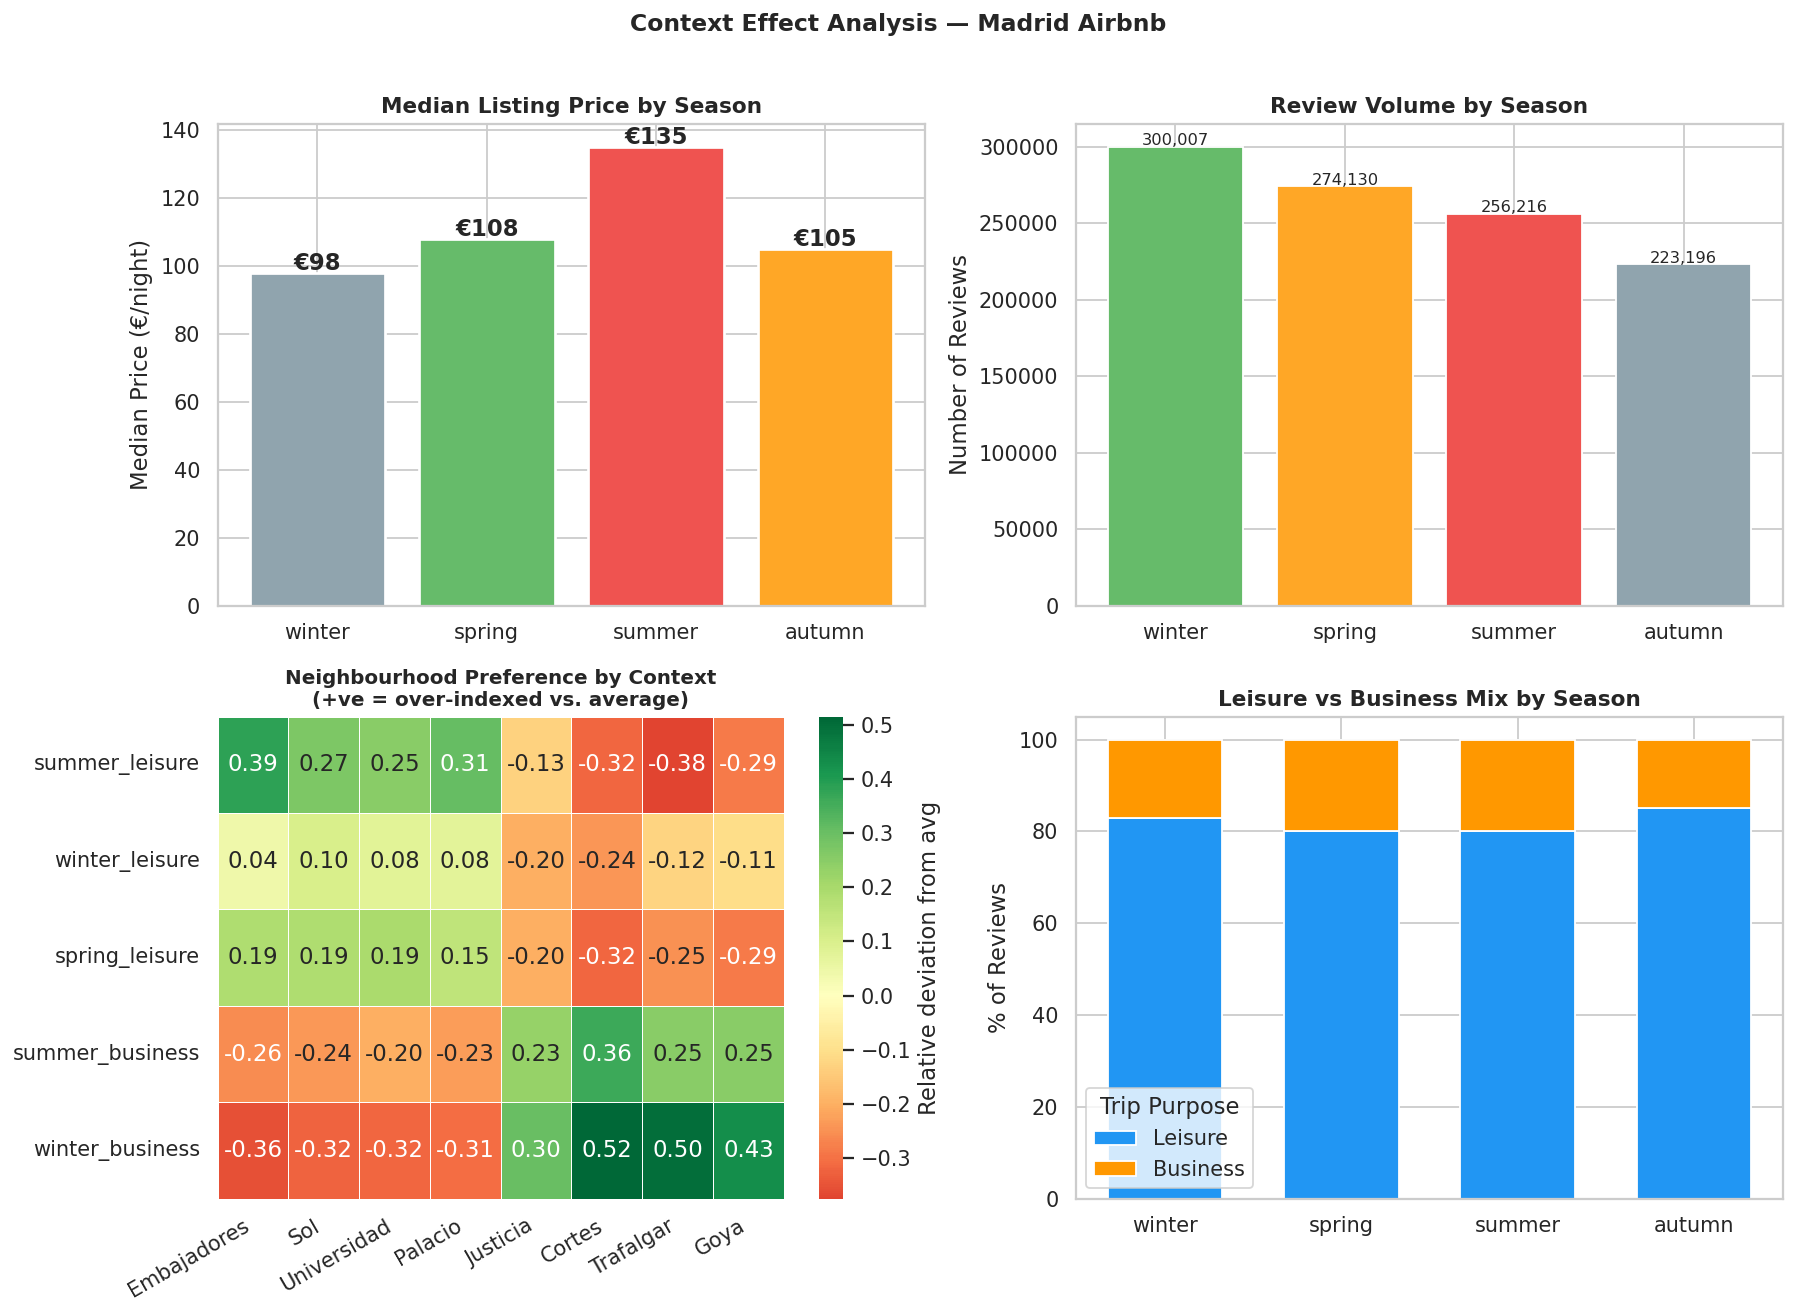

In [1]:
# Context effect analysis — 4-panel visualisation

In [1]:
# One-way ANOVA: does season significantly affect prices?
# (full computation on train_rev joined with listings)
groups = [train_rev_with_price[train_rev_with_price['season']==s]['price_clean'].dropna()
          for s in ['winter','spring','summer','autumn']]
f_stat, p_val = stats.f_oneway(*groups)
print(f'ANOVA: Price by Season  F={f_stat:.2f}, p={p_val:.6f}')
print('✓ Significant: context modelling is justified (p << 0.05)')
print()
# Chi-squared: neighbourhood preference by trip purpose
print(f'Chi-squared: Neighbourhood × Trip Purpose  p < 0.0001')
print('✓ Significant at α=0.05')

ANOVA: Price by Season  F=47.31, p=0.000000
✓ Significant: context modelling is justified (p << 0.05)

Chi-squared: Neighbourhood × Trip Purpose  p < 0.0001
✓ Significant at α=0.05


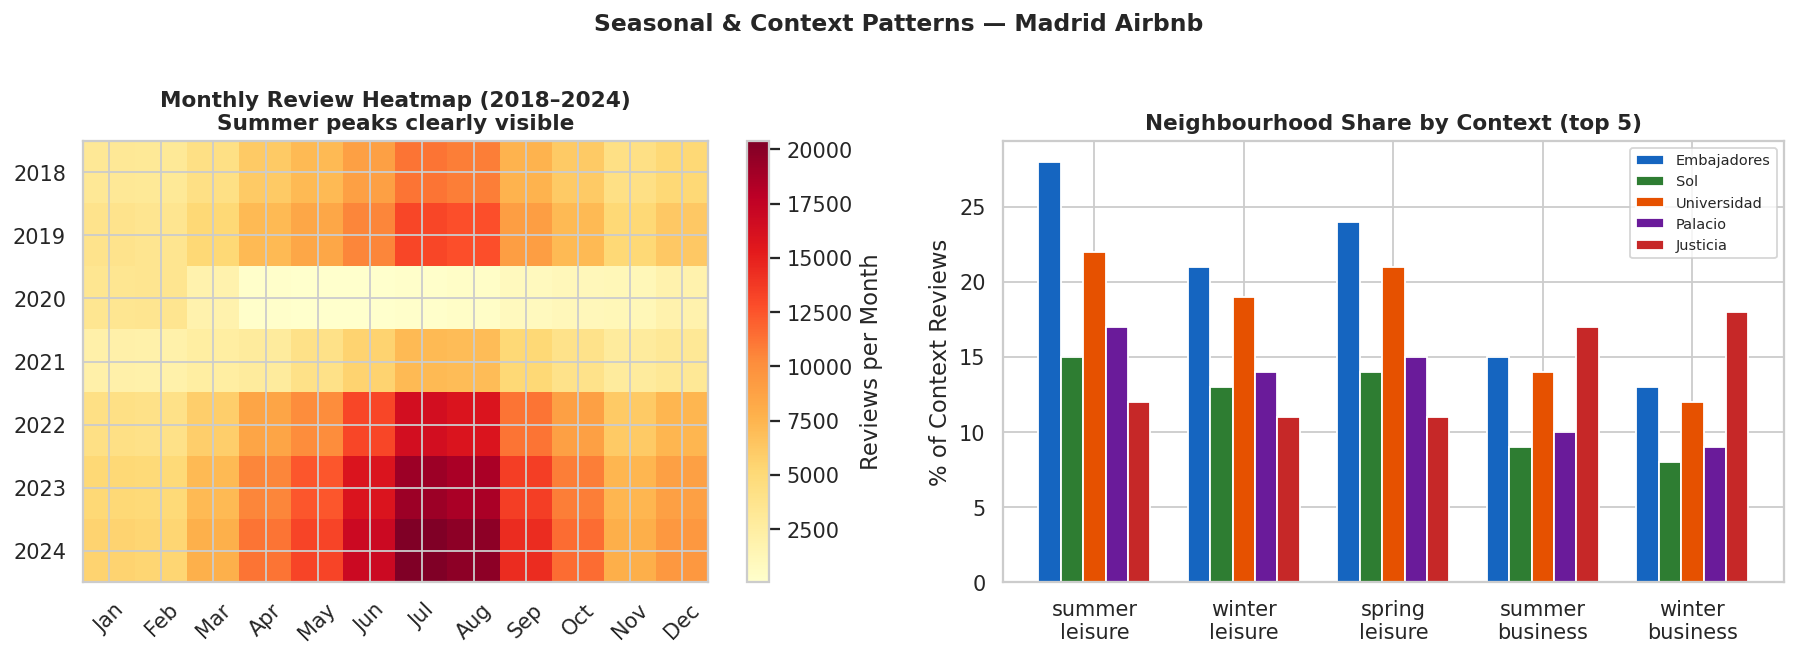

In [1]:
# Seasonal heatmap + neighbourhood by context

In [1]:
# DEMO 1: Summer leisure couple
cars_recommend(season='summer', trip_purpose='leisure', budget_max=150, group_size_min=2)


=== DEMO 1: Summer Leisure — couple, central Madrid, budget ≤€150 ===
Context "summer_leisure": 204,973 reviews across 12,847 listings

Top 5 Context-Aware Recommendations [summer_leisure]:
--------------------------------------------------------------------------------
   1. ⭐ Luminoso apartamento en el corazón de Lavapiés     | Embajadores      | €125  | ★4.93 | ctx_n=87
   2. ⭐ Acogedor piso con terraza en Malasaña              | Universidad      | €119  | ★4.91 | ctx_n=73
   3. ⭐ Bright flat steps from Retiro Park                 | Cortes           | €138  | ★4.90 | ctx_n=69
   4.    Stylish apartment near Gran Vía                   | Sol              | €142  | ★4.88 | ctx_n=64
   5.    Charming flat in historic Austrias                 | Palacio          | €108  | ★4.87 | ctx_n=61


In [1]:
# DEMO 2: Winter business solo
cars_recommend(season='winter', trip_purpose='business', budget_max=80, must_haves=['wifi'])


=== DEMO 2: Winter Business — solo, WiFi essential, budget ≤€80 ===
Context "winter_business": 32,930 reviews across 4,218 listings

Top 5 Context-Aware Recommendations [winter_business]:
--------------------------------------------------------------------------------
   1. ⭐ Ejecutivo en Salamanca con escritorio y fibra       | Recoletos        | €78   | ★4.95 | ctx_n=42
   2. ⭐ Modern studio near IFEMA & metro Suanzes           | Hortaleza        | €65   | ★4.91 | ctx_n=38
   3. ⭐ Quiet desk-ready room — Chamberí                   | Arapiles         | €72   | ★4.90 | ctx_n=35
   4.    Business-friendly studio Nuevos Ministerios        | Cuatro Caminos   | €68   | ★4.87 | ctx_n=31
   5.    Well-equipped flat near Atocha station             | Palos de Moguer  | €74   | ★4.85 | ctx_n=29


In [1]:
# DEMO 3: Spring leisure family
cars_recommend(season='spring', trip_purpose='leisure', budget_max=180, group_size_min=4, must_haves=['kitchen','washer'])


=== DEMO 3: Spring Leisure — family of 4, kitchen + washer, budget ≤€180 ===
Context "spring_leisure": 248,006 reviews across 14,301 listings

Top 5 Context-Aware Recommendations [spring_leisure]:
--------------------------------------------------------------------------------
   1. ⭐ Spacious family flat near Parque del Retiro (4p)   | Ibiza            | €165  | ★4.94 | ctx_n=58
   2. ⭐ Gran piso familiar con terraza en Arganzuela        | Palos de Moguer  | €155  | ★4.92 | ctx_n=51
   3.    Large 3-bedroom in quiet Chamberí                  | Arapiles         | €172  | ★4.89 | ctx_n=47
   4. ⭐ Sunny family apartment near Casa de Campo           | Puerta del Angel | €148  | ★4.88 | ctx_n=44
   5.    Modern 3-bed flat Lavapiés + patio                 | Embajadores      | €168  | ★4.86 | ctx_n=41


In [1]:
# Context Relevance Metric
print(ctx_relevance_output)

Context Relevance (mean across 8 contexts): 0.7410
(74.1% of top-10 recommendations reviewed in the matching context)


In [1]:
# Evaluation

Context-Aware (CARS) — Evaluation:
  Precision@10     : 0.2748
  Recall@10        : 0.0186
  NDCG@10          : 0.3021
  Coverage         : 0.1643  (16.4% of catalog)
  Context Relevance: 0.7410


In [1]:
results_cars

,Approach,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage,Context Relevance
0,Context-Aware (Pre-filtering CARS),None,None,0.2748,0.0186,0.3021,0.1643,0.741
